In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("data/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.shape
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

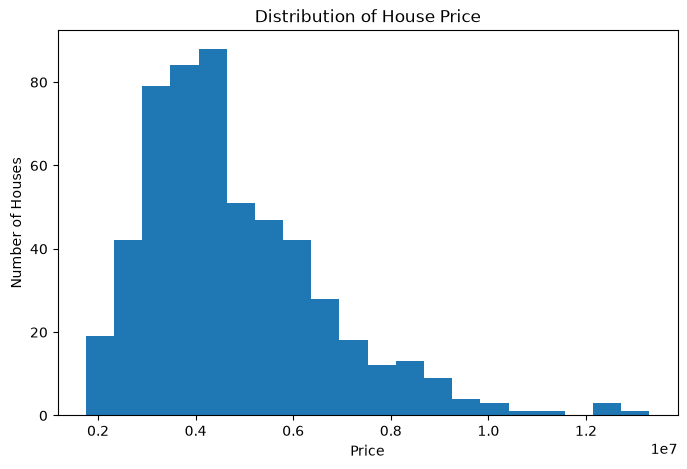

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['price'],bins=20)
plt.title("Distribution of House Price")
plt.xlabel('Price')
plt.ylabel('Number of Houses')
plt.show()

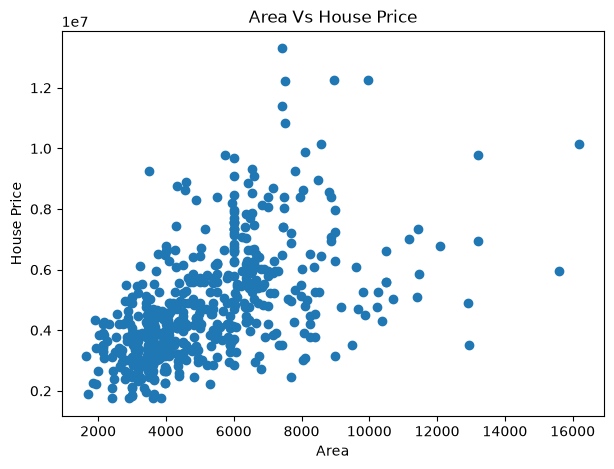

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(df['area'],df['price'])
plt.title("Area Vs House Price")
plt.xlabel('Area')
plt.ylabel('House Price')
plt.show()

In [10]:
numeric_df=df.select_dtypes(include=['int64','float64'])
numeric_df.corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


In [11]:
binary_columns=[
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_columns:
    df[col]=df[col].map({'yes':1,'no':0})

In [12]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [13]:
df['furnishingstatus'].unique()

<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str

In [14]:
df['mainroad'].unique()

array([1, 0])

In [15]:
df=pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    dtype=int
)

In [16]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_furnished       545 non-null    int64
 13  f

In [18]:
X=df.drop('price',axis=1)
y=df['price']

In [19]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


In [20]:
y.head()

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

In [21]:
from  sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
print(X_train.shape)
print(X_test.shape)

(436, 14)
(109, 14)


In [23]:
print(y_train.shape)
print(y_test.shape)

(436,)
(109,)


In [24]:
from  sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[ 235.97, 76778.7 ,1094444.79,..., 180175.63, 53293.81,-233469.44]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['area','bedrooms','bathrooms',...,'furnishingstatus_furnished', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.986e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [25]:
y_pred=model.predict(X_test)

In [26]:
y_pred[:10]

array([5164653.90033967, 7224722.29802167, 3109863.24240338,
       4612075.3272256 , 3294646.25725955, 3532275.09556558,
       5611774.56836476, 6368145.98732718, 2722856.95689985,
       2629405.61585782])

In [27]:
y_test[:10]

316    4060000
77     6650000
360    3710000
90     6440000
493    2800000
209    4900000
176    5250000
249    4543000
516    2450000
426    3353000
Name: price, dtype: int64

In [28]:
from  sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [29]:
mae=mean_absolute_error(y_test,y_pred)
print("MAE",mae)

MAE 970043.4039201641


In [30]:
mse=mean_squared_error(y_test,y_pred)
print("MSE",mse)

MSE 1754318687330.664


In [31]:
rmse=mean_squared_error(y_test,y_pred)**0.5
print("RMSE",rmse)

RMSE 1324506.9600914388


In [32]:
r2=r2_score(y_test,y_pred)
print("R2_Score",r2)

R2_Score 0.6529242642153184


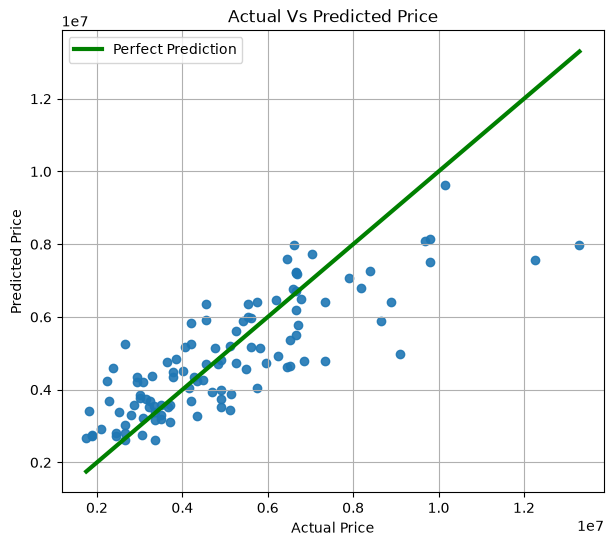

In [33]:
plt.figure(figsize=(7,6))

plt.scatter(y_test,y_pred,alpha=0.9)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color='green',
    linewidth=3,
    label='Perfect Prediction'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Vs Predicted Price")

plt.legend()
plt.grid(True)
plt.show()


In [34]:
coefficients=pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':model.coef_
})

coefficients=coefficients.sort_values(by='Coefficient',ascending=False)

coefficients

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
11,furnishingstatus_furnished,1.801756e+05


In [35]:
import joblib

joblib.dump(model,"house_price_model.pkl")

['house_price_model.pkl']

In [36]:
loaded_model=joblib.load("house_price_model.pkl")

In [37]:
import pandas as pd
new_house=pd.DataFrame({
    "area":[6000],
    "bedrooms":[3],
    "bathrooms":[2],
    "stories":[2],
    "mainroad":[1],
    "guestroom":[0],
    "basement":[1],
    "hotwaterheating":[0],
    "airconditioning":[1],
    "parking":[2],
    "prefarea":[1],
    "furnishingstatus_furnished":[0],
    "furnishingstatus_semi-furnished":[1],
    "furnishingstatus_unfurnished":[0]
})

predicted_price=loaded_model.predict(new_house)
print("Predicted Price:₹",predicted_price[0])

Predicted Price:₹ 7412314.485915294


In [38]:
from  sklearn.tree import DecisionTreeRegressor

dt_model=DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train,y_train)
dt_pred=dt_model.predict(X_test)


In [39]:
from  sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
print("Decision tree Results")
print("MAE:",mean_absolute_error(y_test,dt_pred))
print("RMSE:",mean_squared_error(y_test,dt_pred)**0.5)

print("R2:",r2_score(y_test,dt_pred))

Decision tree Results
MAE: 1280133.0275229358
RMSE: 1731349.0385012683
R2: 0.40695858460408285


In [40]:
from  sklearn.ensemble import RandomForestRegressor

rf_model=RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)

In [41]:
print("Random Forest Results")
print("MAE:",mean_absolute_error(y_test,rf_pred))
print("RMSE:",mean_squared_error(y_test,rf_pred)**0.5)
print("R2:",r2_score(y_test,rf_pred))

Random Forest Results
MAE: 1019527.5454128442
RMSE: 1400219.4230978563
R2: 0.6121105579188428


In [ ]:
def predict_house_price(
    area,
    bedrooms,
    bathrooms,
    stories,
    mainroad,
    guestroom,
    basement,
    hotwaterheating,
    airconditioning,
    parking,
    prefarea,
    furnishing_status
):
    # One-Hot Encoding
    furnished = 1 if furnishing_status == "furnished" else 0
    semi = 1 if furnishing_status == "semi-furnished" else 0
    unfurnished = 1 if furnishing_status == "unfurnished" else 0

    new_house = pd.DataFrame({
        "area": [area],
        "bedrooms": [bedrooms],
        "bathrooms": [bathrooms],
        "stories": [stories],
        "mainroad": [mainroad],
        "guestroom": [guestroom],
        "basement": [basement],
        "hotwaterheating": [hotwaterheating],
        "airconditioning": [airconditioning],
        "parking": [parking],
        "prefarea": [prefarea],
        "furnishingstatus_furnished": [furnished],
        "furnishingstatus_semi-furnished": [semi-furnished],
        "furnishingstatus_unfurnished": [unfurnished]
    })

    prediction = loaded_model.predict(new_house)

    return prediction[0]

In [46]:
price=predict_house_price(
    area=6000,
    bedrooms=3,
    bathrooms=2,
    stories=2,
    mainroad=1,
    guestroom=0,
    basement=1,
    hotwaterheating=0,
    airconditioning=1,
    parking=2,
    prefarea=1,
    furnishing_status='semi-furnished'
)

print(f"Predicted Price: ₹{price:,.2f}")

Predicted Price: ₹7,412,314.49
